In [41]:
# ============================================================
# COWRIE DEC HYPERPARAMETER + PREPROCESSING TUNING
# ============================================================

import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LATENT_DIMS = [2, 4, 8]
N_CLUSTERS = [3, 4, 5, 6, 8]

# Features with strongly skewed non-negative distributions
LOG_FEATURES = [
    "dur",
    "sbytes",
    "dbytes",
    "rate",
    "sload",
    "dload",
    "sinpkt",
    "dinpkt",
    "sjit",
    "djit",
    "tcprtt",
    "synack",
    "ackdat"
]

# Number of DEC iterations for tuning.
# Keep this lower than the final 500-iteration run
# to make the grid search faster.
TUNE_MAXITER = 300
UPDATE_INTERVAL = 50
TOL = 0.001

AE_EPOCHS = 20
BATCH_SIZE = 256


# ============================================================
# 3. PREPARE RAW COWRIE DATA
# ============================================================

X_raw_df = cowrie_df[cowrie_features].copy()

X_raw_df.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

raw_medians = X_raw_df.median()

X_raw_df = X_raw_df.fillna(raw_medians)


# ============================================================
# 4. CREATE TWO PREPROCESSING VARIANTS
# ============================================================

# ---------- Variant A: StandardScaler only ----------

scaler_standard = StandardScaler()

X_standard = scaler_standard.fit_transform(
    X_raw_df
)


# ---------- Variant B: log1p + StandardScaler ----------

X_log_df = X_raw_df.copy()

for feature in LOG_FEATURES:

    if feature in X_log_df.columns:

        # All these features should be non-negative.
        # Clip tiny negative numerical values just in case.
        X_log_df[feature] = np.log1p(
            np.clip(
                X_log_df[feature].values,
                a_min=0,
                a_max=None
            )
        )

scaler_log = StandardScaler()

X_log = scaler_log.fit_transform(
    X_log_df
)


print("Standard preprocessing shape:", X_standard.shape)
print("Log preprocessing shape     :", X_log.shape)


# ============================================================
# 5. DEC CLUSTERING LAYER
# ============================================================

class ClusteringLayer(Layer):

    def __init__(
        self,
        n_clusters,
        alpha=1.0,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.n_clusters = n_clusters
        self.alpha = alpha

    def build(self, input_shape):

        input_dim = int(input_shape[-1])

        self.clusters = self.add_weight(
            shape=(
                self.n_clusters,
                input_dim
            ),
            initializer="glorot_uniform",
            trainable=True,
            name="cluster_centers"
        )

        super().build(input_shape)

    def call(self, inputs):

        squared_distance = tf.reduce_sum(
            tf.square(
                tf.expand_dims(
                    inputs,
                    axis=1
                )
                - self.clusters
            ),
            axis=2
        )

        q = 1.0 / (
            1.0
            + squared_distance / self.alpha
        )

        q = tf.pow(
            q,
            (self.alpha + 1.0) / 2.0
        )

        q = q / tf.reduce_sum(
            q,
            axis=1,
            keepdims=True
        )

        return q


# ============================================================
# 6. TARGET DISTRIBUTION
# ============================================================

def target_distribution(q):

    weight = (
        q ** 2
    ) / (
        np.sum(q, axis=0)
        + 1e-10
    )

    return (
        weight
        / (
            np.sum(
                weight,
                axis=1,
                keepdims=True
            )
            + 1e-10
        )
    )


# ============================================================
# 7. TRAIN ONE DEC CONFIGURATION
# ============================================================

def train_dec_configuration(
    X,
    latent_dim,
    n_clusters,
    preprocessing_name
):

    tf.keras.backend.clear_session()

    input_dim = X.shape[1]


    # --------------------------------------------------------
    # AUTOENCODER
    # --------------------------------------------------------

    inputs = Input(
        shape=(input_dim,),
        name="input"
    )

    x = Dense(
        32,
        activation="relu"
    )(inputs)

    x = Dense(
        16,
        activation="relu"
    )(x)

    latent = Dense(
        latent_dim,
        activation="linear",
        name="latent"
    )(x)

    x = Dense(
        16,
        activation="relu"
    )(latent)

    x = Dense(
        32,
        activation="relu"
    )(x)

    outputs = Dense(
        input_dim,
        activation="linear",
        name="reconstruction"
    )(x)


    autoencoder = Model(
        inputs,
        outputs
    )

    encoder = Model(
        inputs,
        latent
    )


    # --------------------------------------------------------
    # AE PRETRAINING
    # --------------------------------------------------------

    autoencoder.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse"
    )

    autoencoder.fit(
        X,
        X,
        epochs=AE_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        verbose=0
    )


    # --------------------------------------------------------
    # LATENT REPRESENTATION
    # --------------------------------------------------------

    latent_data = encoder.predict(
        X,
        batch_size=BATCH_SIZE,
        verbose=0
    )


    # --------------------------------------------------------
    # K-MEANS INITIALIZATION
    # --------------------------------------------------------

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=SEED,
        n_init=20
    )

    initial_labels = kmeans.fit_predict(
        latent_data
    )

    initial_centers = kmeans.cluster_centers_


    # --------------------------------------------------------
    # BUILD DEC
    # --------------------------------------------------------

    clustering_layer = ClusteringLayer(
        n_clusters=n_clusters,
        name="clustering"
    )

    cluster_output = clustering_layer(
        encoder.output
    )

    dec_model = Model(
        encoder.input,
        cluster_output
    )

    clustering_layer.set_weights(
        [initial_centers]
    )

    dec_model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="kld"
    )


    # --------------------------------------------------------
    # DEC TRAINING
    # --------------------------------------------------------

    start_time = time.time()

    q = dec_model.predict(
        X,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    p = target_distribution(q)

    y_pred_last = q.argmax(axis=1)

    final_iteration = TUNE_MAXITER

    for ite in range(TUNE_MAXITER):

        if ite % UPDATE_INTERVAL == 0:

            q = dec_model.predict(
                X,
                batch_size=BATCH_SIZE,
                verbose=0
            )

            p = target_distribution(q)

            y_pred = q.argmax(axis=1)

            if ite > 0:

                delta_label = np.mean(
                    y_pred != y_pred_last
                )

                if delta_label < TOL:

                    final_iteration = ite
                    break

            y_pred_last = y_pred.copy()


        dec_model.train_on_batch(
            X,
            p
        )

        final_iteration = ite + 1


    training_time = (
        time.time()
        - start_time
    )


    # --------------------------------------------------------
    # FINAL ASSIGNMENTS
    # --------------------------------------------------------

    q_final = dec_model.predict(
        X,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    labels = q_final.argmax(
        axis=1
    )


    # --------------------------------------------------------
    # CHECK OCCUPIED CLUSTERS
    # --------------------------------------------------------

    occupied_clusters = len(
        np.unique(labels)
    )


    # If DEC collapses into one cluster,
    # internal metrics cannot be calculated.
    if occupied_clusters < 2:

        silhouette = np.nan
        db = np.nan
        ch = np.nan

    else:

        silhouette = silhouette_score(
            X,
            labels
        )

        db = davies_bouldin_score(
            X,
            labels
        )

        ch = calinski_harabasz_score(
            X,
            labels
        )


    mean_confidence = np.mean(
        np.max(
            q_final,
            axis=1
        )
    )


    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    result = {

        "Preprocessing":
            preprocessing_name,

        "Latent_Dim":
            latent_dim,

        "Clusters":
            n_clusters,

        "Occupied_Clusters":
            occupied_clusters,

        "Silhouette":
            silhouette,

        "Davies_Bouldin":
            db,

        "Calinski_Harabasz":
            ch,

        "Mean_Confidence":
            mean_confidence,

        "Training_Time":
            training_time,

        "Iterations":
            final_iteration
    }

    return result


# ============================================================
# 8. RUN FULL GRID
# ============================================================

all_results = []

total_configs = (
    len(LATENT_DIMS)
    * len(N_CLUSTERS)
    * 2
)

config_number = 0


for preprocessing_name, X_current in [

    ("StandardScaler", X_standard),

    ("Log1p + StandardScaler", X_log)

]:

    for latent_dim in LATENT_DIMS:

        for n_clusters in N_CLUSTERS:

            config_number += 1

            print(
                f"\n[{config_number}/{total_configs}] "
                f"{preprocessing_name} | "
                f"latent={latent_dim} | "
                f"K={n_clusters}"
            )

            result = train_dec_configuration(
                X_current,
                latent_dim,
                n_clusters,
                preprocessing_name
            )

            all_results.append(
                result
            )

            print(
                f"Silhouette = "
                f"{result['Silhouette']:.4f} | "
                f"DB = "
                f"{result['Davies_Bouldin']:.4f} | "
                f"CH = "
                f"{result['Calinski_Harabasz']:.2f} | "
                f"Confidence = "
                f"{result['Mean_Confidence']:.4f} | "
                f"Occupied = "
                f"{result['Occupied_Clusters']} | "
                f"Time = "
                f"{result['Training_Time']:.2f}s"
            )


# ============================================================
# 9. RESULTS TABLE
# ============================================================

tuning_results = pd.DataFrame(
    all_results
)

print("\n========================================")
print("FULL COWRIE DEC TUNING RESULTS")
print("========================================")

display(
    tuning_results.sort_values(
        by="Silhouette",
        ascending=False
    ).reset_index(drop=True)
)

Standard preprocessing shape: (1800, 17)
Log preprocessing shape     : (1800, 17)

[1/30] StandardScaler | latent=2 | K=3
Silhouette = 0.3581 | DB = 1.1838 | CH = 723.27 | Confidence = 0.9526 | Occupied = 3 | Time = 7.23s

[2/30] StandardScaler | latent=2 | K=4
Silhouette = 0.3069 | DB = 1.4443 | CH = 695.11 | Confidence = 0.8855 | Occupied = 4 | Time = 7.44s

[3/30] StandardScaler | latent=2 | K=5
Silhouette = 0.2863 | DB = 1.5168 | CH = 550.17 | Confidence = 0.8748 | Occupied = 5 | Time = 5.14s

[4/30] StandardScaler | latent=2 | K=6
Silhouette = 0.1836 | DB = 1.6922 | CH = 425.01 | Confidence = 0.6643 | Occupied = 6 | Time = 4.41s

[5/30] StandardScaler | latent=2 | K=8
Silhouette = 0.2624 | DB = 1.6039 | CH = 485.76 | Confidence = 0.6947 | Occupied = 8 | Time = 6.00s

[6/30] StandardScaler | latent=4 | K=3
Silhouette = 0.3088 | DB = 1.2790 | CH = 655.92 | Confidence = 0.9380 | Occupied = 3 | Time = 3.90s

[7/30] StandardScaler | latent=4 | K=4
Silhouette = 0.3073 | DB = 1.4791 | CH

,Preprocessing,Latent_Dim,Clusters,Occupied_Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Mean_Confidence,Training_Time,Iterations
0,StandardScaler,2,3,3,0.358065,1.183774,723.268136,0.952572,7.230346,300
1,Log1p + StandardScaler,4,4,4,0.355348,1.353502,911.419847,0.854919,4.098823,300
2,Log1p + StandardScaler,4,3,3,0.353697,1.382999,1090.369156,0.932876,3.806623,250
3,Log1p + StandardScaler,4,6,6,0.342347,1.231376,833.469718,0.818010,4.132128,300
4,Log1p + StandardScaler,8,4,4,0.339624,1.492205,865.563516,0.900301,4.132442,300
5,Log1p + StandardScaler,8,5,5,0.333658,1.454556,805.777984,0.849361,4.257198,300
6,Log1p + StandardScaler,8,3,3,0.328509,1.345245,1003.756190,0.929428,4.116376,300
7,Log1p + StandardScaler,8,8,8,0.328090,1.962261,642.866920,0.725890,4.450629,300
8,StandardScaler,8,3,3,0.326937,1.200802,712.789853,0.937998,4.070608,300
9,Log1p + StandardScaler,2,3,3,0.326773,1.397760,1000.394957,0.909187,4.146394,300


In [44]:
# ============================================================
# MULTI-METRIC RANKING
# ============================================================

rank_df = tuning_results.copy()

valid = (
    rank_df["Occupied_Clusters"] >= 2
)

rank_df = rank_df[valid].copy()

rank_df["Silhouette_Rank"] = (
    rank_df["Silhouette"]
    .rank(
        ascending=False,
        method="min"
    )
)

rank_df["DB_Rank"] = (
    rank_df["Davies_Bouldin"]
    .rank(
        ascending=True,
        method="min"
    )
)

rank_df["CH_Rank"] = (
    rank_df["Calinski_Harabasz"]
    .rank(
        ascending=False,
        method="min"
    )
)

rank_df["Time_Rank"] = (
    rank_df["Training_Time"]
    .rank(
        ascending=True,
        method="min"
    )
)

rank_df["Overall_Rank_Score"] = (
    rank_df["Silhouette_Rank"]
    + rank_df["DB_Rank"]
    + rank_df["CH_Rank"]
    + rank_df["Time_Rank"]
) / 4


rank_df = rank_df.sort_values(
    by="Overall_Rank_Score",
    ascending=True
).reset_index(drop=True)


print("========================================")
print("COWRIE DEC RANKING")
print("========================================")

display(rank_df)

COWRIE DEC RANKING


,Preprocessing,Latent_Dim,Clusters,Occupied_Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Mean_Confidence,Training_Time,Iterations,Silhouette_Rank,DB_Rank,CH_Rank,Time_Rank,Overall_Rank_Score
0,Log1p + StandardScaler,4,3,3,0.353697,1.382999,1090.369156,0.932876,3.806623,250,3.0,9.0,1.0,1.0,3.50
1,Log1p + StandardScaler,4,4,4,0.355348,1.353502,911.419847,0.854919,4.098823,300,2.0,8.0,5.0,6.0,5.25
2,Log1p + StandardScaler,8,3,3,0.328509,1.345245,1003.756190,0.929428,4.116376,300,7.0,7.0,2.0,7.0,5.75
3,Log1p + StandardScaler,4,6,6,0.342347,1.231376,833.469718,0.818010,4.132128,300,4.0,3.0,7.0,9.0,5.75
4,StandardScaler,8,3,3,0.326937,1.200802,712.789853,0.937998,4.070608,300,9.0,2.0,14.0,5.0,7.50
5,Log1p + StandardScaler,2,3,3,0.326773,1.397760,1000.394957,0.909187,4.146394,300,10.0,10.0,3.0,13.0,9.00
6,StandardScaler,4,3,3,0.308840,1.279043,655.919918,0.938021,3.902938,250,15.0,4.0,17.0,2.0,9.50
7,Log1p + StandardScaler,8,4,4,0.339624,1.492205,865.563516,0.900301,4.132442,300,5.0,18.0,6.0,10.0,9.75
8,Log1p + StandardScaler,2,5,5,0.312929,1.447722,827.130021,0.801518,4.068055,300,13.0,15.0,8.0,4.0,10.00
9,StandardScaler,2,3,3,0.358065,1.183774,723.268136,0.952572,7.230346,300,1.0,1.0,13.0,29.0,11.00


In [45]:
best_config = rank_df.iloc[0]

print("========================================")
print("BEST COWRIE DEC CONFIGURATION")
print("========================================")

print(
    best_config[
        [
            "Preprocessing",
            "Latent_Dim",
            "Clusters",
            "Occupied_Clusters",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
            "Mean_Confidence",
            "Training_Time",
            "Iterations"
        ]
    ]
)

BEST COWRIE DEC CONFIGURATION
Preprocessing        Log1p + StandardScaler
Latent_Dim                                4
Clusters                                  3
Occupied_Clusters                         3
Silhouette                         0.353697
Davies_Bouldin                     1.382999
Calinski_Harabasz               1090.369156
Mean_Confidence                    0.932876
Training_Time                      3.806623
Iterations                              250
Name: 0, dtype: object


In [46]:
# ============================================================
# FINAL COWRIE DEC MODEL
# Best configuration from tuning
# Log1p + StandardScaler
# Latent = 4
# K = 3
# ============================================================

FINAL_LATENT_DIM = 4
FINAL_N_CLUSTERS = 3

X_final = X_log.copy()

input_dim = X_final.shape[1]

print("Final input shape:", X_final.shape)
print("Input dimension:", input_dim)

Final input shape: (1800, 17)
Input dimension: 17


In [47]:
# ============================================================
# FINAL AUTOENCODER
# ============================================================

tf.keras.backend.clear_session()

inputs = Input(
    shape=(input_dim,),
    name="input"
)

x = Dense(
    32,
    activation="relu"
)(inputs)

x = Dense(
    16,
    activation="relu"
)(x)

latent = Dense(
    FINAL_LATENT_DIM,
    activation="linear",
    name="latent"
)(x)

x = Dense(
    16,
    activation="relu"
)(latent)

x = Dense(
    32,
    activation="relu"
)(x)

outputs = Dense(
    input_dim,
    activation="linear",
    name="reconstruction"
)(x)

final_autoencoder = Model(
    inputs,
    outputs,
    name="Final_Cowrie_Autoencoder"
)

final_encoder = Model(
    inputs,
    latent,
    name="Final_Cowrie_Encoder"
)

final_autoencoder.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

final_autoencoder.fit(
    X_final,
    X_final,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.9871 - val_loss: 0.8769
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.9391 - val_loss: 0.8349
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8898 - val_loss: 0.7892
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8348 - val_loss: 0.7371
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.7717 - val_loss: 0.6769
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.7012 - val_loss: 0.6121
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6278 - val_loss: 0.5465
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.5569 - val_loss: 0.4855
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4942 - val_loss: 0.4339
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4432 - val_loss: 0.3914
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4003 - val_loss: 0.3548
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3626 - val_loss: 0.3233
E

In [48]:
# ============================================================
# K-MEANS INITIALIZATION
# ============================================================

final_latent = final_encoder.predict(
    X_final,
    batch_size=256,
    verbose=0
)

print("Final latent shape:", final_latent.shape)

final_kmeans = KMeans(
    n_clusters=FINAL_N_CLUSTERS,
    random_state=SEED,
    n_init=20
)

final_initial_labels = final_kmeans.fit_predict(
    final_latent
)

final_centers = final_kmeans.cluster_centers_

print("\nInitial K-Means distribution:")
print(
    pd.Series(
        final_initial_labels
    ).value_counts().sort_index()
)

Final latent shape: (1800, 4)

Initial K-Means distribution:
0    477
1    693
2    630
Name: count, dtype: int64


In [49]:
# ============================================================
# FINAL DEC
# ============================================================

final_clustering_layer = ClusteringLayer(
    n_clusters=FINAL_N_CLUSTERS,
    name="clustering"
)

final_cluster_output = final_clustering_layer(
    final_encoder.output
)

final_dec = Model(
    final_encoder.input,
    final_cluster_output,
    name="Final_Cowrie_DEC"
)

final_clustering_layer.set_weights(
    [final_centers]
)

final_dec.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="kld"
)

In [50]:
# ============================================================
# FINAL DEC TRAINING
# ============================================================

maxiter = 500
update_interval = 50
tol = 0.001

q = final_dec.predict(
    X_final,
    batch_size=256,
    verbose=0
)

p = target_distribution(q)

y_pred_last = q.argmax(axis=1)

start_time = time.time()

final_iteration = 0

for ite in range(maxiter):

    if ite % update_interval == 0:

        q = final_dec.predict(
            X_final,
            batch_size=256,
            verbose=0
        )

        p = target_distribution(q)

        y_pred = q.argmax(axis=1)

        if ite > 0:

            delta_label = np.mean(
                y_pred != y_pred_last
            )

            print(
                f"Iteration {ite}: "
                f"label change = "
                f"{delta_label:.6f}"
            )

            if delta_label < tol:

                print(
                    "DEC convergence reached."
                )

                final_iteration = ite
                break

        y_pred_last = y_pred.copy()

    final_dec.train_on_batch(
        X_final,
        p
    )

    final_iteration = ite + 1

final_training_time = time.time() - start_time

print("\nFinal DEC training completed.")
print("Iterations:", final_iteration)
print(
    f"Training time: "
    f"{final_training_time:.2f} seconds"
)

Iteration 50: label change = 0.015000
Iteration 100: label change = 0.007222
Iteration 150: label change = 0.005556
Iteration 200: label change = 0.001667
Iteration 250: label change = 0.001111
Iteration 300: label change = 0.001111
Iteration 350: label change = 0.000556
DEC convergence reached.

Final DEC training completed.
Iterations: 350
Training time: 5.84 seconds


In [51]:
# ============================================================
# FINAL CLUSTER ASSIGNMENTS
# ============================================================

q_final = final_dec.predict(
    X_final,
    batch_size=256,
    verbose=0
)

final_labels = np.argmax(
    q_final,
    axis=1
)

print("Final q shape:", q_final.shape)

print("\nFinal cluster distribution:")
print(
    pd.Series(
        final_labels
    ).value_counts().sort_index()
)

print("\nFinal mean confidence:")
print(
    q_final.max(axis=1).mean()
)

Final q shape: (1800, 3)

Final cluster distribution:
0    485
1    694
2    621
Name: count, dtype: int64

Final mean confidence:
0.9394905


In [52]:
# ============================================================
# FINAL METRICS
# ============================================================

final_silhouette = silhouette_score(
    X_final,
    final_labels
)

final_db = davies_bouldin_score(
    X_final,
    final_labels
)

final_ch = calinski_harabasz_score(
    X_final,
    final_labels
)

print("\n========================================")
print("FINAL COWRIE DEC")
print("========================================")

print(
    f"Silhouette       : "
    f"{final_silhouette:.4f}"
)

print(
    f"Davies-Bouldin   : "
    f"{final_db:.4f}"
)

print(
    f"Calinski-Harabasz: "
    f"{final_ch:.4f}"
)

print(
    f"Mean Confidence  : "
    f"{q_final.max(axis=1).mean():.4f}"
)

print(
    f"Training Time    : "
    f"{final_training_time:.2f} s"
)

print(
    f"Iterations       : "
    f"{final_iteration}"
)


FINAL COWRIE DEC
Silhouette       : 0.3457
Davies-Bouldin   : 1.2971
Calinski-Harabasz: 1075.9285
Mean Confidence  : 0.9395
Training Time    : 5.84 s
Iterations       : 350


In [53]:
# ==========================================
# FINAL CLUSTER DISTRIBUTION
# ==========================================

print(
    pd.Series(final_labels)
    .value_counts()
    .sort_index()
)

0    485
1    694
2    621
Name: count, dtype: int64


In [55]:
# ==========================================
# PREPARE FINAL COWRIE RESULTS
# ==========================================

final_results = cowrie_df.copy()

# Add the final DEC cluster assigned to each session
final_results["dec_cluster"] = final_labels

print("Shape:", final_results.shape)

print("\nCluster distribution:")
print(
    final_results["dec_cluster"]
    .value_counts()
    .sort_index()
)

Shape: (1800, 30)

Cluster distribution:
dec_cluster
0    485
1    694
2    621
Name: count, dtype: int64


In [57]:
# ==========================================
# CLUSTER × ATTACK CATEGORY
# ==========================================

cluster_attack = pd.crosstab(
    final_results["attack_cat"],
    final_results["dec_cluster"]
)

print(cluster_attack)

dec_cluster                          0    1    2
attack_cat                                      
botnet_malware_download             72  107   55
brute_force_only                     0    0  222
evasion_anti_forensics              70  108   50
privilege_escalation                 1  157   55
reconnaissance                       9  182   73
zero_day_buffer_overflow           162    0   55
zero_day_covert_tunnel               0  140   53
zero_day_obfuscated_memory_attack  171    0   58


In [58]:
# ==========================================
# ROW-NORMALIZED PERCENTAGES
# ==========================================

cluster_attack_pct = pd.crosstab(
    final_results["attack_cat"],
    final_results["dec_cluster"],
    normalize="index"
) * 100

print(
    cluster_attack_pct.round(2)
)

dec_cluster                            0      1       2
attack_cat                                             
botnet_malware_download            30.77  45.73   23.50
brute_force_only                    0.00   0.00  100.00
evasion_anti_forensics             30.70  47.37   21.93
privilege_escalation                0.47  73.71   25.82
reconnaissance                      3.41  68.94   27.65
zero_day_buffer_overflow           74.65   0.00   25.35
zero_day_covert_tunnel              0.00  72.54   27.46
zero_day_obfuscated_memory_attack  74.67   0.00   25.33


In [59]:
# ==========================================
# ZERO-DAY BEHAVIOR ANALYSIS
# ==========================================

zero_day_mask = (
    final_results["attack_cat"]
    .astype(str)
    .str.startswith("zero_day")
)

zero_day_results = final_results[
    zero_day_mask
].copy()

print(
    "Zero-day sessions:",
    len(zero_day_results)
)

print("\nZero-day × cluster:")
print(
    pd.crosstab(
        zero_day_results["attack_cat"],
        zero_day_results["dec_cluster"]
    )
)

print("\nZero-day percentages:")
print(
    (
        pd.crosstab(
            zero_day_results["attack_cat"],
            zero_day_results["dec_cluster"],
            normalize="index"
        ) * 100
    ).round(2)
)

Zero-day sessions: 639

Zero-day × cluster:
dec_cluster                          0    1   2
attack_cat                                     
zero_day_buffer_overflow           162    0  55
zero_day_covert_tunnel               0  140  53
zero_day_obfuscated_memory_attack  171    0  58

Zero-day percentages:
dec_cluster                            0      1      2
attack_cat                                            
zero_day_buffer_overflow           74.65   0.00  25.35
zero_day_covert_tunnel              0.00  72.54  27.46
zero_day_obfuscated_memory_attack  74.67   0.00  25.33


In [60]:
# ==========================================
# ZERO-DAY CONFIDENCE
# ==========================================

zero_day_confidence = q_final[
    zero_day_mask
].max(axis=1)

print(
    "Zero-day mean confidence:",
    zero_day_confidence.mean()
)

print(
    "Zero-day minimum confidence:",
    zero_day_confidence.min()
)

print(
    "Zero-day maximum confidence:",
    zero_day_confidence.max()
)

Zero-day mean confidence: 0.94378
Zero-day minimum confidence: 0.62456405
Zero-day maximum confidence: 0.953566


In [61]:
# ==========================================
# DOMINANT BEHAVIOR PER CLUSTER
# ==========================================

cluster_behavior = (
    final_results
    .groupby("dec_cluster")["attack_cat"]
    .value_counts()
    .groupby(level=0)
    .head(1)
)

print(cluster_behavior)

dec_cluster  attack_cat                       
0            zero_day_obfuscated_memory_attack    171
1            reconnaissance                       182
2            brute_force_only                     222
Name: count, dtype: int64


In [62]:
# ==========================================
# CLUSTER DOMINANT BEHAVIOR + PURITY
# ==========================================

purity_rows = []

for cluster in sorted(final_results["dec_cluster"].unique()):

    cluster_data = final_results[
        final_results["dec_cluster"] == cluster
    ]

    counts = cluster_data["attack_cat"].value_counts()

    dominant_behavior = counts.index[0]
    dominant_count = counts.iloc[0]

    purity = dominant_count / len(cluster_data)

    purity_rows.append({
        "Cluster": cluster,
        "Dominant_Behavior": dominant_behavior,
        "Dominant_Count": dominant_count,
        "Cluster_Size": len(cluster_data),
        "Purity": purity
    })

purity_df = pd.DataFrame(purity_rows)

print(purity_df)

   Cluster                  Dominant_Behavior  Dominant_Count  Cluster_Size  \
0        0  zero_day_obfuscated_memory_attack             171           485   
1        1                     reconnaissance             182           694   
2        2                   brute_force_only             222           621   

     Purity  
0  0.352577  
1  0.262248  
2  0.357488  


In [63]:
# ==========================================
# ZERO-DAY PROPORTION PER CLUSTER
# ==========================================

final_results["is_zero_day"] = (
    final_results["attack_cat"]
    .astype(str)
    .str.startswith("zero_day")
)

zero_day_cluster_summary = (
    final_results
    .groupby("dec_cluster")["is_zero_day"]
    .agg(
        total_sessions="count",
        zero_day_sessions="sum"
    )
)

zero_day_cluster_summary["zero_day_percentage"] = (
    zero_day_cluster_summary["zero_day_sessions"]
    / zero_day_cluster_summary["total_sessions"]
    * 100
)

print(
    zero_day_cluster_summary.round(2)
)

             total_sessions  zero_day_sessions  zero_day_percentage
dec_cluster                                                        
0                       485                333                68.66
1                       694                140                20.17
2                       621                166                26.73


In [64]:
# ==========================================
# BEHAVIORAL PROFILE OF EACH CLUSTER
# ==========================================

cluster_profile = (
    final_results
    .groupby("dec_cluster")[cowrie_features]
    .mean()
)

print(
    cluster_profile.round(3)
)

               dur  spkts  dpkts  sbytes    dbytes      rate    sload  \
dec_cluster                                                             
0            1.420  1.621  5.524  35.573  1461.522  2271.536  361.662   
1            9.747  3.546  5.415  48.200  1374.215   199.558   64.062   
2            0.244  0.000  4.000   0.000     0.000     0.000    0.000   

                 dload  sinpkt  dinpkt   sjit   djit  tcprtt  synack  ackdat  \
dec_cluster                                                                    
0            17810.623   0.322   0.326  0.082  0.493   0.074   0.033   0.406   
1             1532.401   1.625   2.226  0.542  4.060   0.073   0.033   4.038   
2                0.000   0.000   0.091  0.000  0.074   0.073   0.033   0.000   

             ct_srv_src  ct_src_ltm  
dec_cluster                          
0               241.600     241.600  
1               129.520     129.520  
2               185.631     185.631  


In [65]:
# ==========================================
# STANDARDIZED CLUSTER PROFILE
# ==========================================

from sklearn.preprocessing import StandardScaler

profile_scaler = StandardScaler()

cluster_profile_scaled = pd.DataFrame(
    profile_scaler.fit_transform(
        cluster_profile
    ),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

print(
    cluster_profile_scaled.round(2)
)

              dur  spkts  dpkts  sbytes  dbytes  rate  sload  dload  sinpkt  \
dec_cluster                                                                   
0           -0.56  -0.07   0.78    0.37    0.77  1.41   1.39   1.41   -0.46   
1            1.41   1.26   0.63    0.99    0.64 -0.61  -0.49  -0.61    1.39   
2           -0.84  -1.19  -1.41   -1.37   -1.41 -0.80  -0.90  -0.80   -0.92   

             dinpkt  sjit  djit  tcprtt  synack  ackdat  ct_srv_src  \
dec_cluster                                                           
0             -0.58 -0.53 -0.59    1.34    1.34   -0.59        1.22   
1              1.41  1.40  1.41   -0.29   -0.29    1.41       -1.23   
2             -0.83 -0.87 -0.82   -1.06   -1.06   -0.82        0.00   

             ct_src_ltm  
dec_cluster              
0                  1.22  
1                 -1.23  
2                  0.00  


In [66]:
# ==========================================
# TOP BEHAVIORAL FEATURES PER CLUSTER
# ==========================================

for cluster in cluster_profile_scaled.index:

    print("\n================================")
    print(f"CLUSTER {cluster}")
    print("================================")

    print(
        cluster_profile_scaled
        .loc[cluster]
        .sort_values(
            ascending=False
        )
        .head(8)
    )


CLUSTER 0
dload         1.409946
rate          1.409757
sload         1.394599
tcprtt        1.342951
synack        1.342951
ct_src_ltm    1.224226
ct_srv_src    1.224226
dpkts         0.783983
Name: 0, dtype: float64

CLUSTER 1
ackdat    1.408297
djit      1.407724
dinpkt    1.407040
dur       1.405076
sjit      1.400353
sinpkt    1.389140
spkts     1.258294
sbytes    0.993550
Name: 1, dtype: float64

CLUSTER 2
ct_src_ltm    0.001037
ct_srv_src    0.001037
dload        -0.800045
rate         -0.802033
ackdat       -0.816064
djit         -0.821054
dinpkt       -0.826725
dur          -0.841535
Name: 2, dtype: float64


In [67]:
# ==========================================
# FINAL 4-D DEC LATENT REPRESENTATION
# ==========================================

final_latent = final_encoder.predict(
    X_final,
    batch_size=256,
    verbose=0
)

print("Latent shape:", final_latent.shape)

Latent shape: (1800, 4)


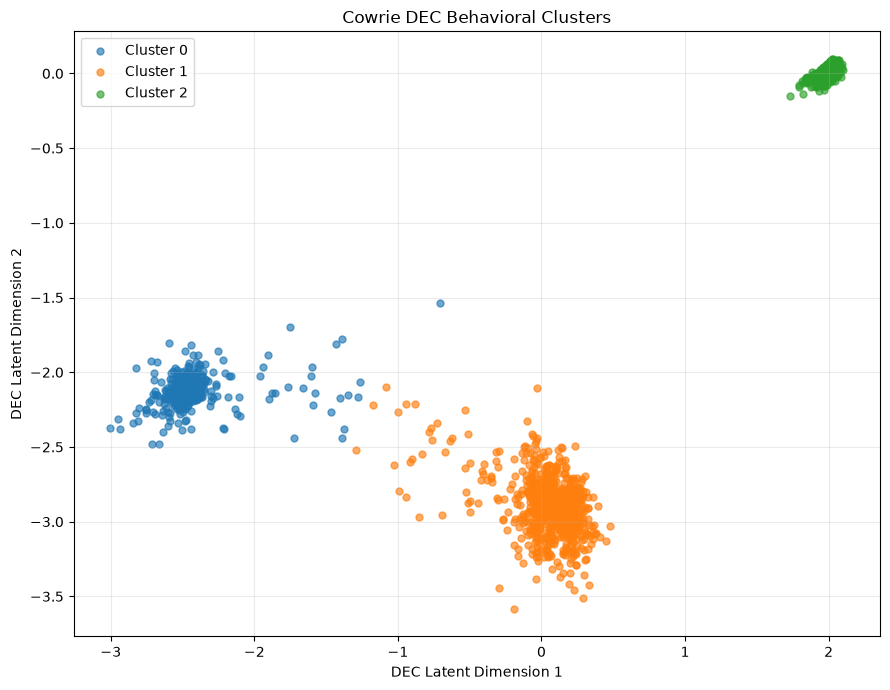

In [68]:
# ==========================================
# DEC LATENT SPACE — FIRST TWO DIMENSIONS
# ==========================================

plt.figure(figsize=(9, 7))

for cluster in sorted(np.unique(final_labels)):

    mask = final_labels == cluster

    plt.scatter(
        final_latent[mask, 0],
        final_latent[mask, 1],
        s=25,
        alpha=0.65,
        label=f"Cluster {cluster}"
    )

plt.xlabel("DEC Latent Dimension 1")
plt.ylabel("DEC Latent Dimension 2")
plt.title("Cowrie DEC Behavioral Clusters")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [69]:
# ==========================================
# PCA OF 4-D DEC LATENT SPACE
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=SEED
)

latent_pca = pca.fit_transform(
    final_latent
)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio: [0.76159495 0.2373131 ]
Total explained variance: 0.99890804


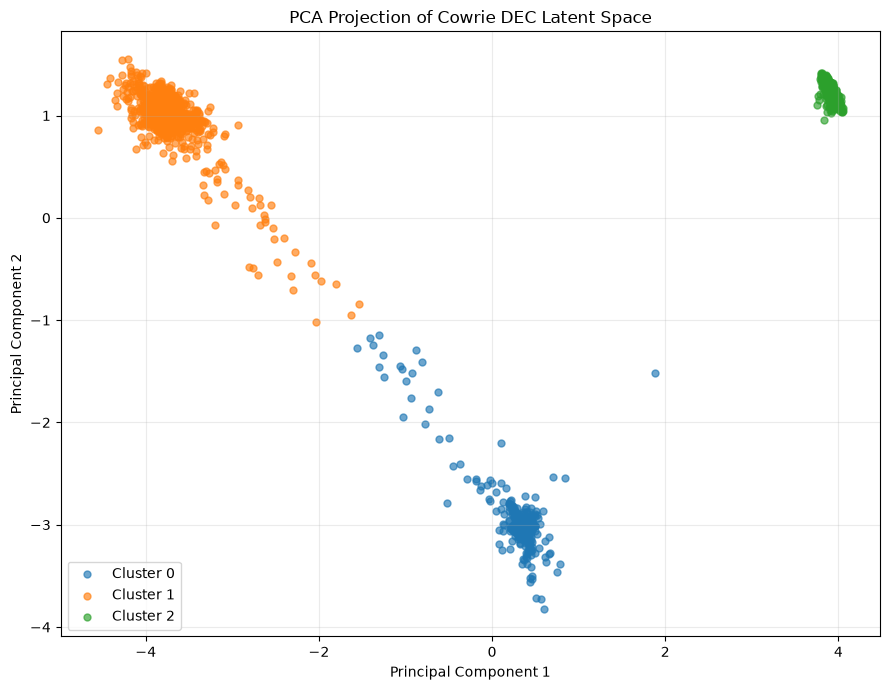

In [70]:
# ==========================================
# PCA VISUALIZATION
# ==========================================

plt.figure(figsize=(9, 7))

for cluster in sorted(np.unique(final_labels)):

    mask = final_labels == cluster

    plt.scatter(
        latent_pca[mask, 0],
        latent_pca[mask, 1],
        s=25,
        alpha=0.65,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Cowrie DEC Latent Space")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

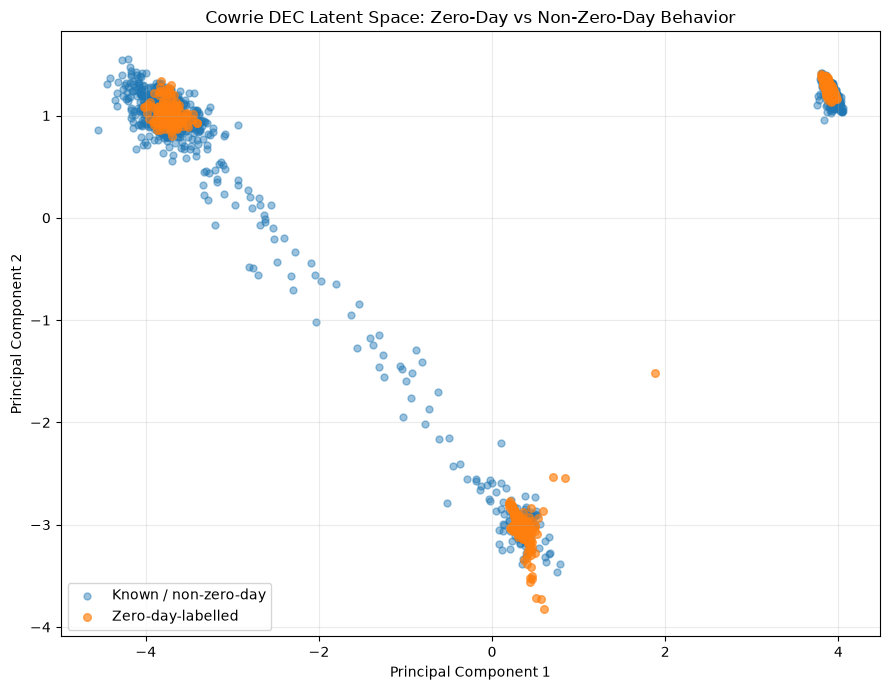

In [71]:
# ==========================================
# ZERO-DAY VS NON-ZERO-DAY
# ==========================================

is_zero_day = (
    final_results["attack_cat"]
    .astype(str)
    .str.startswith("zero_day")
)

plt.figure(figsize=(9, 7))

plt.scatter(
    latent_pca[~is_zero_day, 0],
    latent_pca[~is_zero_day, 1],
    s=25,
    alpha=0.45,
    label="Known / non-zero-day"
)

plt.scatter(
    latent_pca[is_zero_day, 0],
    latent_pca[is_zero_day, 1],
    s=30,
    alpha=0.65,
    label="Zero-day-labelled"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "Cowrie DEC Latent Space: Zero-Day vs Non-Zero-Day Behavior"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [73]:
# ==========================================
# SAVE FINAL COWRIE DEC MODEL
# ==========================================

import os
import json
import joblib

# ------------------------------------------
# 1. Create model directory
# ------------------------------------------

MODEL_DIR = "cowrie_dec_model"

os.makedirs(MODEL_DIR, exist_ok=True)


# ------------------------------------------
# 2. Save ONLY DEC weights
# ------------------------------------------

weights_path = os.path.join(
    MODEL_DIR,
    "cowrie_dec.weights.h5"
)

final_dec.save_weights(weights_path)

print("DEC weights saved:", weights_path)


# ------------------------------------------
# 3. Save fitted scaler
# ------------------------------------------

scaler_path = os.path.join(
    MODEL_DIR,
    "scaler.joblib"
)

joblib.dump(
    scaler_log,
    scaler_path
)

print("Scaler saved:", scaler_path)


# ------------------------------------------
# 4. Save median values
# ------------------------------------------

medians_path = os.path.join(
    MODEL_DIR,
    "medians.joblib"
)

joblib.dump(
    raw_medians,
    medians_path
)

print("Medians saved:", medians_path)


# ------------------------------------------
# 5. Save model configuration
# ------------------------------------------

config = {

    "model_name": "DEC",

    "input_dim": len(cowrie_features),

    "latent_dim": 4,

    "n_clusters": 3,

    "alpha": 1.0,

    "features": cowrie_features,

    "log_features": LOG_FEATURES,

    "preprocessing": {
        "missing_value_strategy": "median",
        "log_transform": "log1p",
        "scaler": "StandardScaler"
    },

    "architecture": {
        "encoder": [
            32,
            16,
            4
        ],
        "decoder": [
            16,
            32,
            17
        ]
    }
}


config_path = os.path.join(
    MODEL_DIR,
    "config.json"
)

with open(
    config_path,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("Configuration saved:", config_path)


# ------------------------------------------
# 6. Display final structure
# ------------------------------------------

print("\n==========================================")
print("MODEL ARTIFACTS SAVED SUCCESSFULLY")
print("==========================================")

print(f"""
{MODEL_DIR}/
│
├── cowrie_dec.weights.h5
├── scaler.joblib
├── medians.joblib
└── config.json
""")

DEC weights saved: cowrie_dec_model\cowrie_dec.weights.h5
Scaler saved: cowrie_dec_model\scaler.joblib
Medians saved: cowrie_dec_model\medians.joblib
Configuration saved: cowrie_dec_model\config.json

MODEL ARTIFACTS SAVED SUCCESSFULLY

cowrie_dec_model/
│
├── cowrie_dec.weights.h5
├── scaler.joblib
├── medians.joblib
└── config.json

